# Fiat-Shamir: de protocolo interactivo a firma no interactiva

**Trabajo Final — Programación Científica 2026-1**

Integrantes:\
Delgado Ortiz, David \
Fonseca Aldana, Miguel Angel\
Moreno Ceballos, Jose Daniel\
Ospina Ocampo, Juan Diego\
Urrutia Manyoma, Haison



## 1. Introducción y motivación

Se seleccionó el esquema Fiat–Shamir porque transforma protocolos de identificación interactivos en protocolos no interactivos mediante funciones hash criptográficas, este tema nos parece atractivo y que puede llegar a aplicar las utilidades aprendidas en computación científica, como dato curioso Fiat-Shamir va reduciendo el costo de comunicación, simplificando la implementación y manteniendo las propiedades de seguridad y privacidad.

El tema fue trabajado en la sección de firmas del curso de criptografía


## 2. Contexto teórico

### 2.1 Protocolo interactivo de conocimiento (base: raíces cuadradas mod N)

El protocolo de **Fiat-Shamir** permite a un **Prover** convencer a un **Verifier** de que conoce un secreto \(s\) sin revelarlo.

Originalmente, es un protocolo **interactivo** que consta de tres pasos:

1. **Compromiso (Commitment):**

   $$
   x = r^2 \pmod{N}
   $$

2. **Reto (Challenge):**

   $$
   e \in \{0,1\}
   $$

3. **Respuesta (Response):**

   $$
   y = r \cdot s^e \pmod{N}
   $$

### 2.2 La transformación de Fiat-Shamir (1986)

En 1986, **Amos Fiat** y **Adi Shamir** propusieron una transformación brillante: reemplazar al **Verifier** generando el reto mediante una función hash criptográfica aplicada al compromiso.

En lugar de que el **Verifier** elija el reto, éste se calcula como

$$
e = H(x),
$$

donde \(H\) es una función hash criptográfica.

Esta transformación elimina la necesidad de interacción entre el **Prover** y el **Verifier**, convirtiendo el protocolo de identificación en un **esquema de firma digital**.

La seguridad de esta transformación depende de modelar la función hash como un **oráculo aleatorio (Random Oracle)**, de modo que el reto sea impredecible y no pueda ser manipulado por el **Prover**.

### 2.3 Zero-knowledge vs. Soundness

_(las dos definiciones trabajadas: qué garantiza cada una y a quién protege)_


In [ ]:
# Imports generales
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import time
import random
import math
from sympy import randprime

# Nota: Usamos `sympy.randprime` para generar números primos grandes de forma eficiente.
# La aritmética modular (potencias) usará la función nativa de Python `pow(base, exp, mod)`,
# la cual está implementada en C y es altamente optimizada (usa exponenciación binaria).

## 3. Implementación del protocolo Fiat-Shamir

### 3.1 Configuración: generación de N = p·q y del secreto

En esta etapa se generan los parámetros globales del protocolo mediante los siguientes pasos:
- Módulo del sistema ($N$): Se eligen dos números primos grandes $p$ y $q$ de forma independiente y aleatoria. Se calcula $N = p \cdot q$. El valor de $N$ se hace público, mientras que $p$ y $q$ permanecen secretos.
- Clave privada ($s$): El Prover elige un número entero secreto $s$ en el rango $1 < s < N$ tal que $\gcd(s, N) = 1$ (es decir, $s$ es coprimo con $N$).
- Clave pública ($v$): El Prover calcula su clave pública mediante la congruencia:$$v \equiv s^2 \pmod N$$
- Oráculo Aleatorio (Heurística de Fiat-Shamir): Para eliminar la interacción directa con el Verifier, se utiliza una función hash criptográfica $H(\cdot)$ (como SHA-256) que actúa como un oráculo aleatorio para generar el reto $e \in \{0, 1\}$ a partir del compromiso $$ x:e = H(x) \pmod 2$$

In [ ]:

def generar_parametros(bits=512):
    """Genera las claves pública y privada para el protocolo Fiat-Shamir.

    Parámetros:
    - bits (int): Tamaño total deseado para el módulo N.

    Retorna:
    - dict: Diccionario con el módulo N, clave secreta s y clave pública v.
    """
    # 1. Generar dos primos grandes p y q de tamaño bits/2
    mitad_bits = bits // 2
    p = randprime(2 ** (mitad_bits - 1), 2**mitad_bits)
    q = randprime(2 ** (mitad_bits - 1), 2**mitad_bits)

    while p == q:
        q = randprime(2 ** (mitad_bits - 1), 2**mitad_bits)

    N = p * q

    # 2. Seleccionar clave secreta 's' tal que mcd(s, N) == 1
    while True:
        s = random.randint(2, N - 1)
        if math.gcd(s, N) == 1:
            break

    # 3. Calcular clave pública v = s^2 mod N
    v = pow(s, 2, N)

    return {"N": N, "s": s, "v": v}


def calcular_reto_fiat_shamir(compromiso):
    """Heurística de Fiat-Shamir: Reemplaza al Verificador calculando el reto e =

    H(x) mod 2 a partir del compromiso 'x'.
    """
    # Convertir el compromiso a bytes para la función hash SHA-256
    x_bytes = str(compromiso).encode("utf-8")
    hash_digest = hashlib.sha256(x_bytes).hexdigest()

    # Mapear el hash a un bit {0, 1}
    e = int(hash_digest, 16) % 2
    return e


params = generar_parametros(bits=512)
print("=== Parámetros Generados ===")
print(f"Módulo N ({params['N'].bit_length()} bits): {params['N']}")
print(f"Clave secreta (s): {params['s']}")
print(f"Clave pública (v): {params['v']}")


=== Parámetros Generados ===
Módulo N (512 bits): 8533925637006566168433422297821657987566935040024039313071553272585531874818443609311532787273717182005645045106814137890912567164768215556673754435519827
Clave secreta (s): 6929650394573351942250232638532055190848070817055567939902209469074723483322425150216519687089378562538523667633078544169349622889045130806805287487240905
Clave pública (v): 5879273290813645719316232798701506876964942195580192342892730948340808310395105043007966149967161711580322316637516172725294087553482532593369311797606953


### 3.2 Prover: compromiso y respuesta


3.2. Compromiso del Prover (Commitment)En esta etapa, el Prover inicia el protocolo preparando una cegadora aleatoria que garantizará la propiedad de Cero Conocimiento (Zero-Knowledge):Selección del número aleatorio ($r$): El Prover elige de manera completamente aleatoria un valor efímero $r$ (llamado nonce) en el rango $1 < r < N$ tal que $\gcd(r, N) = 1$.Cálculo del compromiso ($x$): El Prover calcula la evidencia pública o compromiso mediante la operación modular:$$x \equiv r^2 \pmod N$$Seguridad del nonce: El valor de $r$ debe mantenerse estrictamente en secreto y debe ser regenerado para cada nuevo intento. Si un Prover reutiliza el mismo valor de $r$ para diferentes retos, un atacante podría recuperar la clave secreta $s$.

In [ ]:
def generar_compromiso(N):
    """Genera el número aleatorio secreto 'r' (nonce) y calcula el compromiso

    público 'x'.

    Parámetros:
    - N (int): El módulo del sistema generado en la sección 3.1.

    Retorna:
    - tuple: (r, x) donde 'r' es el valor aleatorio secreto y 'x' es el
    compromiso público.
    """
    while True:
        r = random.randint(2, N - 1)
        if math.gcd(r, N) == 1:
            break

    x = pow(r, 2, N)

    return r, x


r, x = generar_compromiso(params["N"])

print("=== Compromiso del Prover (3.2) ===")
print(f"Nonce secreto (r): {r}")
print(f"Compromiso público (x): {x}")

=== Compromiso del Prover (3.2) ===
Nonce secreto (r): 1950441034780054380324138769286465244201975765279154487771565486673022168954023055705504041724909463791454067062994370696583115698278537662362475161095951
Compromiso público (x): 4738061710841203017131312583452551256985327527124629162506545145963766836317710100739167912133159988082460810219473177914866781249206353044563252988343834


### 3.3 El reto vía hash (la transformación de Fiat-Shamir)


3.3. Obtención del Reto y Respuesta del Prover (Challenge & Response)En esta fase se realiza el cálculo del reto determinista y la construcción de la respuesta que se enviará al Verifier:Obtención del reto ($e$): A través de la heurística de Fiat-Shamir (definida en 3.1), el compromiso $x$ se pasa por la función Hash para fijar de forma no interactiva el valor del reto:$$e = H(x) \pmod 2 \quad \in \{0, 1\}$$Cálculo de la respuesta ($y$): El Prover responde mediante la fórmula:$$y \equiv r \cdot s^e \pmod N$$Análisis de los casos:Si $e = 0 \implies y \equiv r \pmod N$: El Prover demuestra que conoce la raíz cuadrada del compromiso $x$.Si $e = 1 \implies y \equiv r \cdot s \pmod N$: El Prover demuestra que conoce la clave secreta $s$ enmascarándola con la cegadora aleatoria $r$.Debido a que $r$ es un número totalmente aleatorio y único para esta sesión, ningún observador externo (ni siquiera el Verifier) puede despejar $s$ a partir de $y$.

In [ ]:
def generar_respuesta(r, s, e, N):
    """Calcula la respuesta del Prover: y = (r * (s^e)) mod N.

    Parámetros:
    - r (int): Nonce secreto del Prover.
    - s (int): Clave secreta del Prover.
    - e (int): Reto (0 o 1) devuelto por la función Hash.
    - N (int): Módulo del sistema.

    Retorna:
    - int: La respuesta 'y'.
    """
    y = (r * pow(s, e, N)) % N
    return y


e = calcular_reto_fiat_shamir(x)
y = generar_respuesta(r, params["s"], e, params["N"])

print("=== Generación de Reto y Respuesta (3.3) ===")
print(f"Reto derivado del Hash (e): {e}")
print(f"Respuesta construida (y):   {y}")

=== Generación de Reto y Respuesta (3.3) ===
Reto derivado del Hash (e): 1
Respuesta construida (y):   5416352953522839743770753117768150517098099630624745372163111116298354527352192645458483439307361503111701756212802439740902237412499310229975203025758026


### 3.4 Verificación


3.4. Verificación de la Prueba por el Verificador (Verification)En la fase final, el Verificador recibe la tupla pública $(x, y)$ y realiza la validación sin necesidad de comunicarse interactivamente con el Prover:Reconstrucción del reto ($e$): El Verificador recalcula de manera idéntica el reto $e$ aplicando la función Hash al compromiso $x$:$$e = H(x) \pmod 2$$Comprobación de la identidad modular: El Verificador comprueba si se satisface la siguiente congruencia:$$y^2 \equiv x \cdot v^e \pmod N$$Demostración de corrección matemática:Sustituyendo la respuesta $y = r \cdot s^e \pmod N$ y la clave pública $v = s^2 \pmod N$:$$y^2 \equiv (r \cdot s^e)^2 \equiv r^2 \cdot (s^2)^e \equiv x \cdot v^e \pmod N$$Si $e = 0 \implies y^2 \equiv r^2 \equiv x \pmod N \quad $Si $e = 1 \implies y^2 \equiv r^2 \cdot s^2 \equiv x \cdot v \pmod N \quad $Si la igualdad se cumple, la prueba es aceptada como legítima.

In [ ]:
def verificar_prueba(x, y, v, N):
    """Verifica la validez de una prueba de Fiat-Shamir no interactiva.

    Parámetros:
    - x (int): Compromiso público del Prover.
    - y (int): Respuesta del Prover.
    - v (int): Clave pública del Prover (v = s^2 mod N).
    - N (int): Módulo del sistema.

    Retorna:
    - bool: True si la prueba es válida, False en caso contrario.
    """
    e_recalculado = calcular_reto_fiat_shamir(x)

    lhs = pow(y, 2, N)

    rhs = (x * pow(v, e_recalculado, N)) % N

    return lhs == rhs


es_valida = verificar_prueba(x, y, params["v"], params["N"])

print("=== Verificación de la Prueba (3.4) ===")
print(f"¿Prueba aceptada por el Verificador?: {es_valida}")

y_falsa = (y + 1) % params["N"]
es_valida_falsa = verificar_prueba(x, y_falsa, params["v"], params["N"])
print(f"¿Prueba alterada aceptada?: {es_valida_falsa}")

=== Verificación de la Prueba (3.4) ===
¿Prueba aceptada por el Verificador?: True
¿Prueba alterada aceptada?: False


## 4. Ejemplo aplicado — Parte A: costo computacional

**Pregunta:** ¿cómo escala el costo de generar y verificar una prueba en función
del tamaño de N (256, 512, 1024, 2048 bits)?

_(medir tiempos de exponenciación modular / generación de parámetros vs. tamaño de N,
graficar en escala log-log)_


In [ ]:
# TODO: medir tiempos para distintos tamaños de N
tamanos_bits = [256, 512, 1024, 2048]
tiempos = []

# for bits in tamanos_bits:
#     t0 = time.time()
#     ...
#     tiempos.append(time.time() - t0)


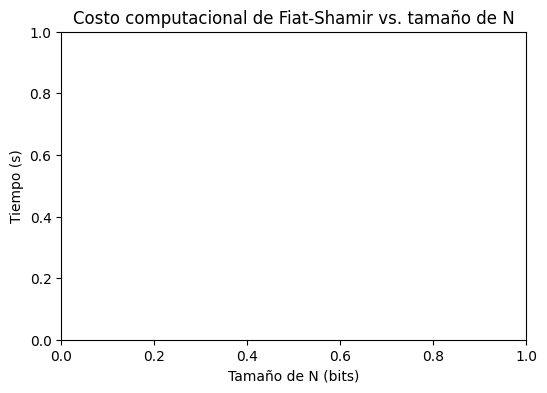

In [ ]:
# TODO: graficar tiempo vs tamaño de N (log-log)
plt.figure(figsize=(6,4))
# plt.plot(tamanos_bits, tiempos, marker='o')
plt.xlabel("Tamaño de N (bits)")
plt.ylabel("Tiempo (s)")
plt.title("Costo computacional de Fiat-Shamir vs. tamaño de N")
plt.show()


## 5. Ejemplo aplicado — Parte B: análisis estadístico del hash (Monte Carlo)

**Pregunta:** ¿el hash se comporta como un generador de retos uniforme e impredecible
(modelo de oráculo aleatorio)? ¿Qué pasa si tuviera sesgos?

_(simular miles de compromisos aleatorios, calcular hash(compromiso), analizar la
distribución de los retos resultantes: uniformidad, colisiones, etc.)_


In [ ]:
# TODO: simulación Monte Carlo de retos generados por hash
n_simulaciones = 100_000
retos = []

# for _ in range(n_simulaciones):
#     compromiso = random.randint(0, 2**256)
#     reto = int(hashlib.sha256(str(compromiso).encode()).hexdigest(), 16)
#     retos.append(reto)


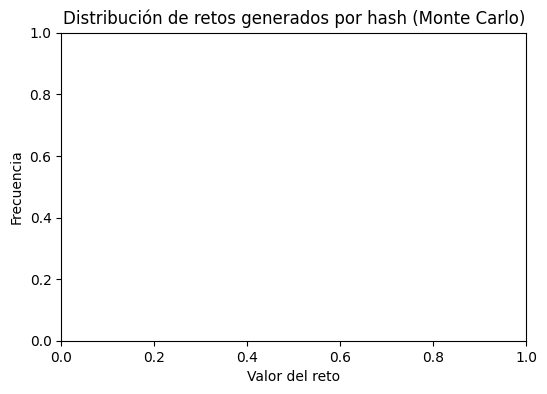

In [ ]:
# TODO: graficar distribución de los retos (histograma) y comentar uniformidad
plt.figure(figsize=(6,4))
# plt.hist(retos, bins=50)
plt.xlabel("Valor del reto")
plt.ylabel("Frecuencia")
plt.title("Distribución de retos generados por hash (Monte Carlo)")
plt.show()


## 6. Conclusiones

_(síntesis breve: qué muestran las partes A y B, y cómo conectan con la seguridad
y eficiencia real de Fiat-Shamir)_


## 7. Opinión del grupo


- **David Delgado Ortiz:** _(pendiente)_
- **Miguel Angel Fonseca Aldana:** En Criptografía solo había visto la parte teórica y no lo había puesto en práctica hasta este trabajo. Me pareció un buen ejercicio poder aplicarlo en Programación Científica, sobre todo viendo lo del método de Montecarlo.
- **Jose Daniel Moreno Ceballos:** _(pendiente)_
- **Juan Diego Ospina Ocampo:** _(pendiente)_
- **Haison Urrutia Manyoma:** _(pendiente)_
